<a href="https://colab.research.google.com/github/ManalJaffary/Heart-disease-detection/blob/main/HEART.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import numpy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import metrics
from time import time
import time
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [ ]:
dataset= pd.read_csv('/content/gdrive/MyDrive/heart.csv')
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
dataset.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [ ]:
dataset.info

<bound method DataFrame.info of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2

In [ ]:
dataset.target.value_counts()

1    526
0    499
Name: target, dtype: int64

In [ ]:
duplicate=dataset[dataset.duplicated()]
duplicate
dataset= dataset.drop_duplicates()
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [ ]:
missing_values= dataset.isnull().sum()
print(missing_values)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
X = dataset.drop(columns=['target'])
Y = dataset['target']


In [ ]:
dataset.shape

(1025, 14)

In [ ]:
Y.shape

(1025,)

In [ ]:
X.shape

(1025, 13)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
835,49,1,2,118,149,0,0,126,0,0.8,2,3,2
137,64,0,0,180,325,0,1,154,1,0.0,2,0,2
534,54,0,2,108,267,0,0,167,0,0.0,2,0,2
495,59,1,0,135,234,0,1,161,0,0.5,1,0,3
244,51,1,2,125,245,1,0,166,0,2.4,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,41,1,2,130,214,0,0,168,0,2.0,1,0,2
71,61,1,0,140,207,0,0,138,1,1.9,2,1,3
106,51,1,0,140,299,0,1,173,1,1.6,2,0,3
270,43,1,0,110,211,0,1,161,0,0.0,2,0,3


In [ ]:
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
527,62,0,0,124,209,0,1,163,0,0.0,2,0,2
359,53,0,2,128,216,0,0,115,0,0.0,2,0,0
447,55,1,0,160,289,0,0,145,1,0.8,1,1,3
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2
621,48,1,0,130,256,1,0,150,1,0.0,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
832,68,1,2,118,277,0,1,151,0,1.0,2,1,3
796,41,1,1,135,203,0,1,132,0,0.0,1,0,1
644,44,1,2,120,226,0,1,169,0,0.0,2,0,2
404,61,1,0,140,207,0,0,138,1,1.9,2,1,3


In [ ]:
y_train.value_counts()

1    423
0    397
Name: target, dtype: int64

In [ ]:
# Define the MLP model
model = Sequential([
    tf.keras.layers.Flatten(input_shape=(X_train.shape[1],)),  # Reshape the input data if needed
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
start_time = time.time()
model.fit(X_train, y_train, epochs=10, batch_size=100)
training_time = time.time() - start_time

# Evaluate the model on the test data
y_pred = (model.predict(X_test)> 0.5).astype("int64")

# Calculate evaluation metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Training Time: {training_time:.2f} seconds")

Epoch 1/10
9/9 [==============================] - 1s 4ms/step - loss: 0.6798 - accuracy: 0.5720
Epoch 2/10
9/9 [==============================] - 0s 3ms/step - loss: 0.6036 - accuracy: 0.6768
Epoch 3/10
9/9 [==============================] - 0s 2ms/step - loss: 0.5900 - accuracy: 0.6805
Epoch 4/10
9/9 [==============================] - 0s 2ms/step - loss: 0.5911 - accuracy: 0.6695
Epoch 5/10
9/9 [==============================] - 0s 2ms/step - loss: 0.5743 - accuracy: 0.6805
Epoch 6/10
9/9 [==============================] - 0s 2ms/step - loss: 0.5617 - accuracy: 0.7085
Epoch 7/10
9/9 [==============================] - 0s 2ms/step - loss: 0.5551 - accuracy: 0.7110
Epoch 8/10
9/9 [==============================] - 0s 2ms/step - loss: 0.5474 - accuracy: 0.7293
Epoch 9/10
9/9 [==============================] - 0s 2ms/step - loss: 0.5460 - accuracy: 0.7329
Epoch 10/10
7/7 [==============================] - 0s 2ms/step
Precision: 0.6744
Recall: 0.5631
F1-score: 0.6138
Accuracy: 0.6439
Traini

In [ ]:
y_pred

array([[1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1]])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create a K-Nearest Neighbors classifier
model = KNeighborsClassifier(n_neighbors=5)

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
F1_score = f1_score(y_test, y_pred)
print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1_score:",F1_score)

Accuracy: 0.7317073170731707
Precision: 0.7307692307692307
Recall: 0.7378640776699029
F1_score: 0.7342995169082126


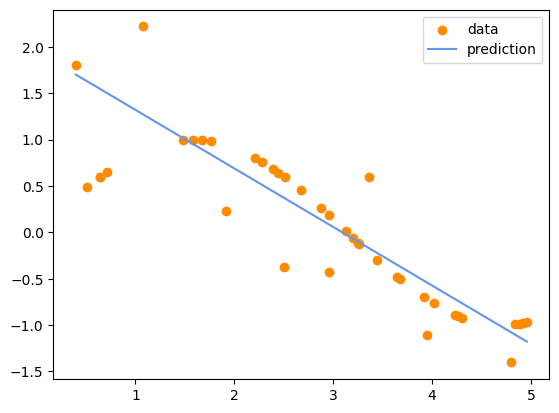

In [ ]:

import matplotlib.pyplot as plt
from sklearn.svm import SVR

# generate synthetic data
X = np.sort(5 * np.random.rand(40, 1),
			axis=0)
y = np.sin(X).ravel()

# add some noise to the data
y[::5] += 3 * (0.5 - np.random.rand(8))

# create an SVR model with a linear kernel
svr = SVR(kernel='linear')

# train the model on the data
svr.fit(X, y)

# make predictions on the data
y_pred = svr.predict(X)

# plot the predicted values against the true values
plt.scatter(X, y, color='darkorange',
			label='data')
plt.plot(X, y_pred, color='cornflowerblue',
		label='prediction')
plt.legend()
plt.show()


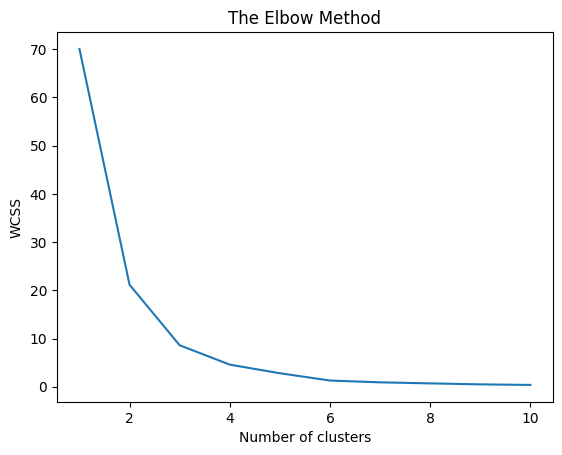

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
  kmeans= KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init= 10, random_state= 0)
  kmeans.fit(X)
  wcss.append(kmeans. inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Silhouette Score: 0.16629935583559352


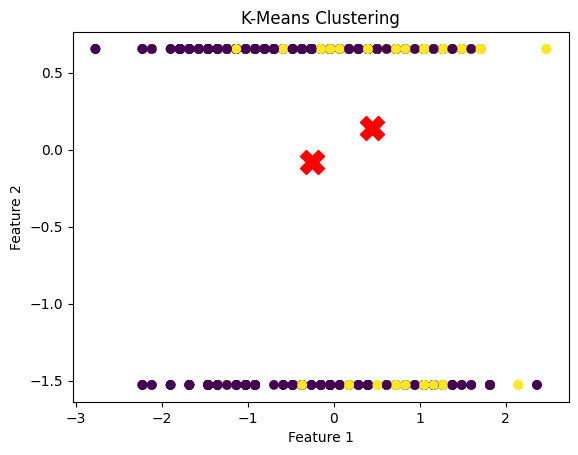

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize the features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Choose the number of clusters
n_clusters = 2

# Create a KMeans instance
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Fit the model to the scaled data
kmeans.fit(X_scaled)

# Predict the clusters for each data point
labels = kmeans.labels_

# Evaluate the clustering performance using silhouette score
silhouette_avg = silhouette_score(X_scaled, labels)
print("Silhouette Score:", silhouette_avg)

#visualization
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, marker='X', c='red')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
F1_score = f1_score(y_test, y_pred)
print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1_score:",F1_score)

Accuracy: 0.8
Precision: 0.7540983606557377
Recall: 0.8932038834951457
F1_score: 0.8177777777777777
